In [1]:
from model_training import ModelTraining
from PIL import Image


In [2]:
train_transforms = {
    'resized': True,
    'padding': False,
    'new_image_size': 400,
    'interpolation': Image.BILINEAR,
    'normalized': False,
    'normalized_mean': [0.485, 0.456, 0.406],
    # TODO should be different for resnet

    # TODO should be different for resnet
    'normalized_std': [0.229, 0.224, 0.225],
    
}

val_transforms = {
    'resized': True,
    'padding': False,
    'new_image_size': 400,
    'interpolation': Image.BILINEAR,
    'normalized': False,
    'normalized_mean': [0.485, 0.456, 0.406],
    # TODO should be different for resnet

    # TODO should be different for resnet
    'normalized_std': [0.229, 0.224, 0.225],
    
}

In [3]:
dataset_info = {
    'label':'Full_Name_Encoded',
    'label_descr':'Full_Name',
    'pre_cropped': True,
}

In [4]:
training_params = {
    'shuffle': True,
    'pin_memory': True,
    'batch_size': 4,
    'num_workers': 0,
    'epochs': 10,
    'frozen_layers': True,
    'optim': 'SGD',
    'lr': 0.1,
    'momentum': 0.9,
    'lr_scheduled_used': True,
    'lr_scheduler': 'ReduceLROnPlateau',
    'ReduceLROnPlateau_mode': 'max',
    'ReduceLROnPlateau_patience': 3,
    'ReduceLROnPlateau_threshold': 0.9,

    # 'lr_sched_step_size': 3,
    # 'lr_sched_gamma': 0.9
}

In [5]:
params = {
    'random_state': 42,
    'train_transforms': train_transforms,
    'val_transforms':val_transforms,
    'dataset_info': dataset_info,
    'training_params': training_params

}
parent_dir= 'C:/Users/joshu_rdnqgbx/Documents/Current Work/Car Recognition Model/data/Car Labelling/Standford Dataset/'

df_path = 'C:/Users/joshu_rdnqgbx/Documents/Current Work/Car Recognition Model/data/Car Labelling/Standford Dataset/df/data_as_df.csv'

In [6]:
model_training = ModelTraining(
                            parent_dir=parent_dir,
                            params=params,
                            full_df_path=df_path,
                            model='temp')

[Resize(size=(400, 400), interpolation=bilinear, max_size=None, antialias=True), ToTensor()]
[Resize(size=(400, 400), interpolation=bilinear, max_size=None, antialias=True), ToTensor()]


c:\Users\joshu_rdnqgbx\anaconda3\envs\FNB_env\Lib\site-packages\numpy\_core\fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


In [7]:
dir(model_training.train_dataset)

['__add__',
 '__annotations__',
 '__class__',
 '__class_getitem__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getitem__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__len__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__orig_bases__',
 '__parameters__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__slots__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_is_protocol',
 'class_values',
 'classes',
 'df',
 'label',
 'label_descr',
 'parent_dir',
 'transformations']

In [8]:
model_training.train_dataset.transformations

Compose(
    Resize(size=(400, 400), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
)

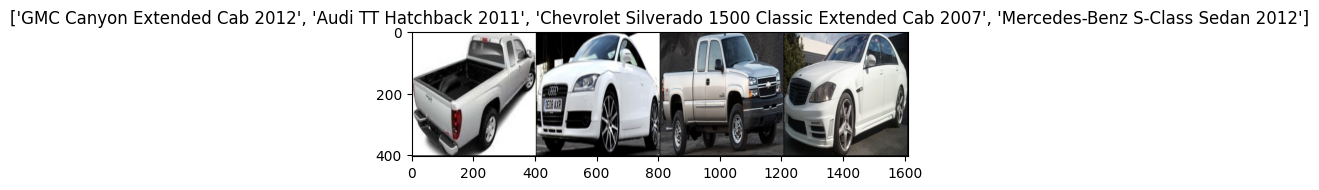

In [10]:
import torchvision
from matplotlib import pyplot as plt

def imshow(inp, title=None):
    """Display image for Tensor."""
    # inp = inp.numpy().transpose((1, 2, 0))
    # mean = np.array([0.485, 0.456, 0.406])
    # std = np.array([0.229, 0.224, 0.225])
    # inp = std * inp + mean
    # inp = np.clip(inp, 0, 1)
    # inp = data_transforms['train'](inp.numpy().transpose((1, 2, 0))).T
    plt.imshow(inp.permute(1, 2, 0))
    if title is not None:
        plt.title(title)
    plt.pause(0.001)  # pause a bit so that plots are updated


# Get a batch of training data
inputs, classes = next(iter(model_training.train_loader))

# # Make a grid from batch
out = torchvision.utils.make_grid(inputs)

class_names = model_training.train_dataset.classes
imshow(out, title=[class_names(x.item()) for x in classes])